In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# Make sure 'SampleSuperstore.csv' is in the exact same folder as this notebook
df = pd.read_csv('SampleSuperstore.csv')

# 2. Simulate the missing 'Order Date' column
# Generate random dates between 2020-01-01 and 2023-12-31 for all 9994 rows
np.random.seed(42) # Keeps the random dates consistent every time you run it
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2023-12-31')
days_between = (end_date - start_date).days

# Create random days to add to the start date
random_days = np.random.randint(0, days_between, size=len(df))
df['Order Date'] = start_date + pd.to_timedelta(random_days, unit='D')

# 3. Check the first 5 rows to confirm the new column is there
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Order Date
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2023-01-31
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2023-12-30
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2022-05-10
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2023-07-18
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2023-02-04


In [2]:
# 1. Inspect data types and non-null counts
print("--- DATASET SUMMARY ---")
df.info()

# 2. Check explicitly for any missing values
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# 3. Check for exact duplicate rows
print("\n--- DUPLICATE ROWS COUNT ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")

--- DATASET SUMMARY ---
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Ship Mode     9994 non-null   str           
 1   Segment       9994 non-null   str           
 2   Country       9994 non-null   str           
 3   City          9994 non-null   str           
 4   State         9994 non-null   str           
 5   Postal Code   9994 non-null   int64         
 6   Region        9994 non-null   str           
 7   Category      9994 non-null   str           
 8   Sub-Category  9994 non-null   str           
 9   Sales         9994 non-null   float64       
 10  Quantity      9994 non-null   int64         
 11  Discount      9994 non-null   float64       
 12  Profit        9994 non-null   float64       
 13  Order Date    9994 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(2), str(8)
memory usage: 1.1 MB

--

In [3]:
# 1. High-Level Key Performance Indicators (KPIs)
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_quantity = df['Quantity'].sum()
profit_margin = (total_profit / total_sales) * 100

print("==========================================")
print("            BUSINESS OVERVIEW             ")
print("==========================================")
print(f"Total Revenue (Sales) : ${total_sales:,.2f}")
print(f"Total Profit          : ${total_profit:,.2f}")
print(f"Overall Profit Margin : {profit_margin:.2f}%")
print(f"Total Units Sold      : {total_quantity:,}")
print("==========================================\n")

# 2. Descriptive Statistics for Numerical Features
print("--- NUMERICAL SUMMARY STATISTICS ---")
df[['Sales', 'Profit', 'Discount', 'Quantity']].describe().T

            BUSINESS OVERVIEW             
Total Revenue (Sales) : $2,297,200.86
Total Profit          : $286,397.02
Overall Profit Margin : 12.47%
Total Units Sold      : 37,873

--- NUMERICAL SUMMARY STATISTICS ---


,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000


C:\Users\saadc\AppData\Local\Temp\ipykernel_2228\3960411176.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=discount_df, x='Discount', y='Profit', ax=axes[1,1], palette='Reds_r')


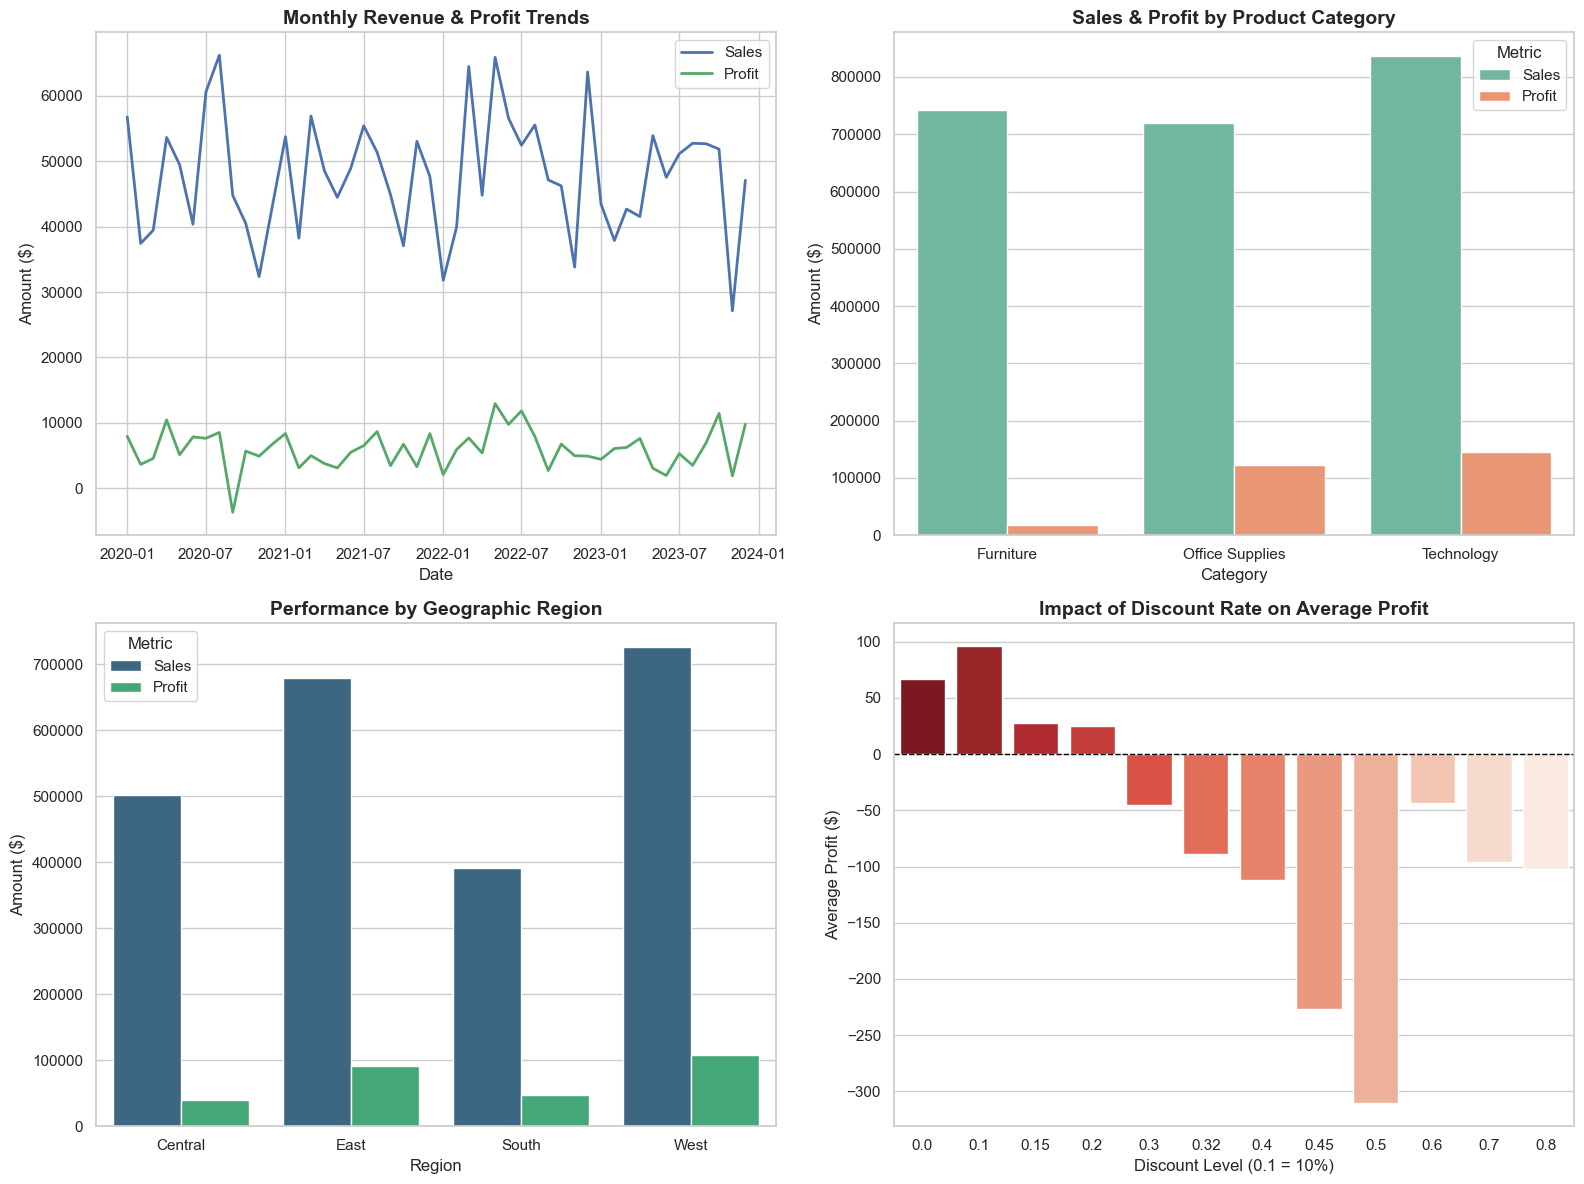

In [4]:
# Set global style for clean visualizations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time-Series: Monthly Sales & Profit Trend
df['YearMonth'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
monthly_df = df.groupby('YearMonth')[['Sales', 'Profit']].sum().reset_index()

sns.lineplot(data=monthly_df, x='YearMonth', y='Sales', ax=axes[0,0], label='Sales', color='b', linewidth=2)
sns.lineplot(data=monthly_df, x='YearMonth', y='Profit', ax=axes[0,0], label='Profit', color='g', linewidth=2)
axes[0,0].set_title('Monthly Revenue & Profit Trends', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Amount ($)')

# 2. Sales & Profit by Product Category
category_df = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()
category_melted = pd.melt(category_df, id_vars=['Category'], value_vars=['Sales', 'Profit'], 
                          var_name='Metric', value_name='Amount')

sns.barplot(data=category_melted, x='Category', y='Amount', hue='Metric', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Sales & Profit by Product Category', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Amount ($)')

# 3. Regional Sales & Profitability
region_df = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()
region_melted = pd.melt(region_df, id_vars=['Region'], value_vars=['Sales', 'Profit'], 
                         var_name='Metric', value_name='Amount')

sns.barplot(data=region_melted, x='Region', y='Amount', hue='Metric', ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Performance by Geographic Region', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Amount ($)')

# 4. Discount Level vs. Average Profit
discount_df = df.groupby('Discount')['Profit'].mean().reset_index()

sns.barplot(data=discount_df, x='Discount', y='Profit', ax=axes[1,1], palette='Reds_r')
axes[1,1].set_title('Impact of Discount Rate on Average Profit', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Discount Level (0.1 = 10%)')
axes[1,1].set_ylabel('Average Profit ($)')
axes[1,1].axhline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()